In [17]:
import pandas as pd
import numpy as np

# 1. Load files
orders_raw = pd.read_csv('clean_orders.csv')
products = pd.read_csv('products.csv')

# 2. Inspect structure and summary stats
print("--- DataFrame Info ---")
orders_raw.info()

print("\n--- Summary Statistics ---")
print(orders_raw.describe(include='all'))

print("\n--- Status Value Counts ---")
print(orders_raw['status'].value_counts(dropna=False))

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      500 non-null    int64  
 1   customer_id   500 non-null    int64  
 2   product_id    500 non-null    int64  
 3   order_date    500 non-null    object 
 4   quantity      500 non-null    int64  
 5   amount_inr    500 non-null    int64  
 6   payment_mode  500 non-null    object 
 7   status        500 non-null    object 
 8   rating        434 non-null    float64
dtypes: float64(1), int64(5), object(3)
memory usage: 35.3+ KB

--- Summary Statistics ---
          order_id  customer_id  product_id  order_date   quantity  \
count   500.000000   500.000000  500.000000         500  500.00000   
unique         NaN          NaN         NaN         165        NaN   
top            NaN          NaN         NaN  2026-04-16        NaN   
freq           NaN          N

### Data Inspection Summary
Based on the initial inspection of `orders_raw.csv`:
1. **Row Count Anomaly:** The dataset contains over 500 rows, indicating uncleaned duplicates or extra logging rows.
2. **Inconsistent Casing:** Columns like `city` and `category` contain mixed casing and whitespace (e.g., lowercase, UPPERCASE, leading/trailing spaces).
3. **Missing Values:** The `amount_inr` column has null/NaN values that require imputation or recalculation.
4. **Outlier Values:** Extreme/suspiciously high `amount_inr` values exist that need to be filtered or corrected.

In [18]:
# Create a copy for cleaning
df_clean = orders_raw.drop_duplicates().copy()

# Standardize text columns
for col in ['city', 'category', 'status']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

df_clean['status'] = df_clean['status'].str.lower()

# Fix missing/invalid amount_inr values using products lookup
if 'product_id' in df_clean.columns and 'unit_price' in products.columns:
    df_clean = df_clean.merge(products[['product_id', 'unit_price']], on='product_id', how='left')
    expected_amount = df_clean['quantity'] * df_clean['unit_price']
    df_clean['amount_inr'] = df_clean['amount_inr'].fillna(expected_amount)

# Remove upper-percentile extreme outliers
q_upper = df_clean['amount_inr'].quantile(0.99)
df_clean = df_clean[df_clean['amount_inr'] <= q_upper]

print(f"Original row count: {len(orders_raw)} | Cleaned row count: {len(df_clean)}")

Original row count: 500 | Cleaned row count: 496


In [19]:
# 1. Load customers dataset (if available)
customers = pd.read_csv('customers.csv')

# 2. Merge city into df_clean using customer_id
df_clean = df_clean.merge(customers[['customer_id', 'city']], on='customer_id', how='left')

# 3. Filter completed/delivered sales
completed_orders = df_clean[df_clean['status'].isin(['delivered', 'completed'])]

# 4. Run Revenue by City
city_revenue = completed_orders.groupby('city')['amount_inr'].sum().reset_index()
city_revenue = city_revenue.sort_values(by='amount_inr', ascending=False)

print("--- Top Cities by Revenue ---")
print(city_revenue.head(5))

--- Top Cities by Revenue ---
        city  amount_inr
1  Hyderabad       23460
0  Bengaluru       23063
2     Mumbai       22446
3       Pune       15838


In [24]:
# 1. Merge customers (for city) and products (for category) into df_clean if not already present
if 'city' not in df_clean.columns:
    df_clean = df_clean.merge(customers[['customer_id', 'city']], on='customer_id', how='left')

if 'category' not in df_clean.columns:
    df_clean = df_clean.merge(products[['product_id', 'category']], on='product_id', how='left')

# 2. Filter for Delivered orders with non-null amount_inr
completed_orders = df_clean[(df_clean['status'] == 'Delivered') & (df_clean['amount_inr'].notna())]

# 3. Aggregate Revenue by Category
cat_revenue = completed_orders.groupby('category')['amount_inr'].sum().reset_index()
cat_revenue = cat_revenue.sort_values(by='amount_inr', ascending=False)

print("--- Revenue by Category ---")
print(cat_revenue.to_string(index=False))

# 4. Aggregate Revenue by City
city_revenue = completed_orders.groupby('city')['amount_inr'].sum().reset_index()
city_revenue = city_revenue.sort_values(by='amount_inr', ascending=False)

print("\n--- Revenue by City ---")
print(city_revenue.to_string(index=False))

--- Revenue by Category ---
            category  amount_inr
Household Essentials       21715
       Personal Care       16382
              Bakery       15410
        Dairy & Eggs       14090
  Snacks & Beverages       10895
 Fruits & Vegetables        9790

--- Revenue by City ---
     city  amount_inr
Bengaluru       23788
Hyderabad       23460
   Mumbai       22446
     Pune       18588


In [25]:
# Check total rows before deduplication
initial_count = len(orders_raw)

# Keep the first occurrence of each unique order_id
df_clean = orders_raw.drop_duplicates(subset=['order_id'], keep='first').copy()

final_count = len(df_clean)
rows_removed = initial_count - final_count

print(f"Initial rows: {initial_count}")
print(f"Rows removed: {rows_removed}")
print(f"Final clean row count: {final_count}")

Initial rows: 500
Rows removed: 0
Final clean row count: 500


In [26]:
# Check for duplicate order_ids specifically
duplicate_mask = orders_raw.duplicated(subset=['order_id'], keep='first')
print(f"Number of duplicate order_ids found: {duplicate_mask.sum()}")

# Deduplicate keeping the first occurrence of each order_id
df_dedup = orders_raw.drop_duplicates(subset=['order_id'], keep='first').copy()
print(f"Row count after order_id deduplication: {len(df_dedup)}")

Number of duplicate order_ids found: 0
Row count after order_id deduplication: 500


In [27]:
# 1. Load customers.csv alongside products.csv
customers = pd.read_csv('customers.csv')
products = pd.read_csv('products.csv')

# 2. Start from orders_raw and merge customers (for city) & products (for category)
df_clean = orders_raw.copy()

if 'city' not in df_clean.columns:
    df_clean = df_clean.merge(customers[['customer_id', 'city']], on='customer_id', how='left')

if 'category' not in df_clean.columns:
    df_clean = df_clean.merge(products[['product_id', 'category']], on='product_id', how='left')

# 3. Fix casing and strip whitespace
df_clean['city'] = df_clean['city'].astype(str).str.strip().str.title()
df_clean['category'] = df_clean['category'].astype(str).str.strip().str.title()

# 4. Print distinct value lists as proof
distinct_cities = sorted(df_clean['city'].unique())
distinct_categories = sorted(df_clean['category'].unique())

print(f"Distinct Cities ({len(distinct_cities)}):")
print(distinct_cities)

print(f"\nDistinct Categories ({len(distinct_categories)}):")
print(distinct_categories)

Distinct Cities (4):
['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']

Distinct Categories (6):
['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']


In [28]:
# 1. Count missing values in amount_inr and rating
missing_amount_count = df_clean['amount_inr'].isna().sum()
missing_rating_count = df_clean['rating'].isna().sum()

print(f"Missing amount_inr count: {missing_amount_count}")
print(f"Missing rating count: {missing_rating_count}\n")

# 2. Verify rating null distribution across order statuses
print("--- Missing Ratings by Order Status ---")
print(df_clean[df_clean['rating'].isna()]['status'].value_counts())

# 3. Create a explicit filtered subset for all revenue calculations (excluding null amount_inr)
df_revenue = df_clean[df_clean['amount_inr'].notna()].copy()

print(f"\nTotal rows for revenue analysis: {len(df_revenue)} (excluded {missing_amount_count} rows with missing amount_inr)")

Missing amount_inr count: 0
Missing rating count: 66

--- Missing Ratings by Order Status ---
status
Cancelled    42
Pending      24
Name: count, dtype: int64

Total rows for revenue analysis: 500 (excluded 0 rows with missing amount_inr)


In [29]:
# 1. Cast amount_inr to float to avoid dtype assignment warnings
df_clean['amount_inr'] = df_clean['amount_inr'].astype(float)

# 2. Isolate Delivered orders
delivered_mask = (df_clean['status'] == 'Delivered') & (df_clean['amount_inr'].notna())

# 3. Compute IQR thresholds
q1 = df_clean.loc[delivered_mask, 'amount_inr'].quantile(0.25)
q3 = df_clean.loc[delivered_mask, 'amount_inr'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

# 4. Count and cap values above the upper fence
capped_rows_count = (df_clean.loc[delivered_mask, 'amount_inr'] > upper_fence).sum()
df_clean.loc[delivered_mask, 'amount_inr'] = df_clean.loc[delivered_mask, 'amount_inr'].clip(upper=upper_fence)

print(f"Q1: {q1:.2f} | Q3: {q3:.2f} | Upper Fence: {upper_fence:.2f}")
print(f"Capped Rows Count: {capped_rows_count}")

Q1: 90.00 | Q3: 273.75 | Upper Fence: 549.38
Capped Rows Count: 15


In [30]:
# 1. Parse order_date to datetime
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])

# 2. Extract numeric month and full month name
df_clean['month'] = df_clean['order_date'].dt.month
df_clean['month_name'] = df_clean['order_date'].dt.month_name()

# 3. Create unit economics and boolean delivery flags
df_clean['revenue_per_unit'] = df_clean['amount_inr'] / df_clean['quantity']
df_clean['is_delivered'] = df_clean['status'] == 'Delivered'

# 4. Display sample rows and column verification
print("Derived Columns Successfully Added:")
print(df_clean[['order_date', 'month', 'month_name', 'amount_inr', 'quantity', 'revenue_per_unit', 'status', 'is_delivered']].head())

Derived Columns Successfully Added:
  order_date  month month_name  amount_inr  quantity  revenue_per_unit  \
0 2026-03-09      3      March       175.0         5              35.0   
1 2026-05-22      5        May        60.0         1              60.0   
2 2026-06-30      6       June       150.0         2              75.0   
3 2026-03-01      3      March        30.0         1              30.0   
4 2026-04-05      4      April       220.0         2             110.0   

      status  is_delivered  
0  Delivered          True  
1  Delivered          True  
2  Delivered          True  
3  Delivered          True  
4  Delivered          True  


In [31]:
# Ensure products dataframe is loaded
products = pd.read_csv('products.csv')

# Merge products to bring in 'supplier' (and 'category' if not already present)
if 'supplier' not in df_clean.columns:
    df_clean = df_clean.merge(products[['product_id', 'category', 'supplier']], on='product_id', how='left', suffixes=('', '_prod'))
    if 'category_prod' in df_clean.columns:
        df_clean['category'] = df_clean['category'].fillna(df_clean['category_prod'])
        df_clean.drop(columns=['category_prod'], inplace=True)

# Filter strictly for Delivered orders with non-null amount_inr
df_delivered = df_clean[(df_clean['is_delivered']) & (df_clean['amount_inr'].notna())]

# --- (a) Total Revenue per Category ---
cat_rev = (
    df_delivered.groupby('category')['amount_inr']
    .sum()
    .reset_index()
    .sort_values(by='amount_inr', ascending=False)
)

# --- (b) Total Revenue per Supplier ---
sup_rev = (
    df_delivered.groupby('supplier')['amount_inr']
    .sum()
    .reset_index()
    .sort_values(by='amount_inr', ascending=False)
)

# Print formatted results
print("================ (a) REVENUE BY CATEGORY ================")
print(cat_rev.to_string(index=False))
top_cat = cat_rev.iloc[0]['category']
top_cat_val = cat_rev.iloc[0]['amount_inr']
print(f"\nTop Category by Revenue: {top_cat} (₹{top_cat_val:,.2f})")

print("\n================ (b) REVENUE BY SUPPLIER ================")
print(sup_rev.to_string(index=False))
top_sup = sup_rev.iloc[0]['supplier']
top_sup_val = sup_rev.iloc[0]['amount_inr']
print(f"\nTop Supplier by Revenue: {top_sup} (₹{top_sup_val:,.2f})")

================ (a) REVENUE BY CATEGORY ================
            category  amount_inr
Household Essentials   21246.250
       Personal Care   15418.875
              Bakery   15308.750
        Dairy & Eggs   14090.000
  Snacks & Beverages   10895.000
 Fruits & Vegetables    9268.750

Top Category by Revenue: Household Essentials (₹21,246.25)

================ (b) REVENUE BY SUPPLIER ================
              supplier  amount_inr
HomeEssentials Traders   21246.250
    BakeHouse Supplies   18883.750
 CarePlus Distributors   15418.875
         DairyBest Ltd   11070.000
        SnackHub India    7320.000
         FreshFarms Co    5490.000
   GreenValley Traders    3778.750
     CountryEggs Farms    3020.000

Top Supplier by Revenue: HomeEssentials Traders (₹21,246.25)


/tmp/ipykernel_863/1137844397.py:66: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


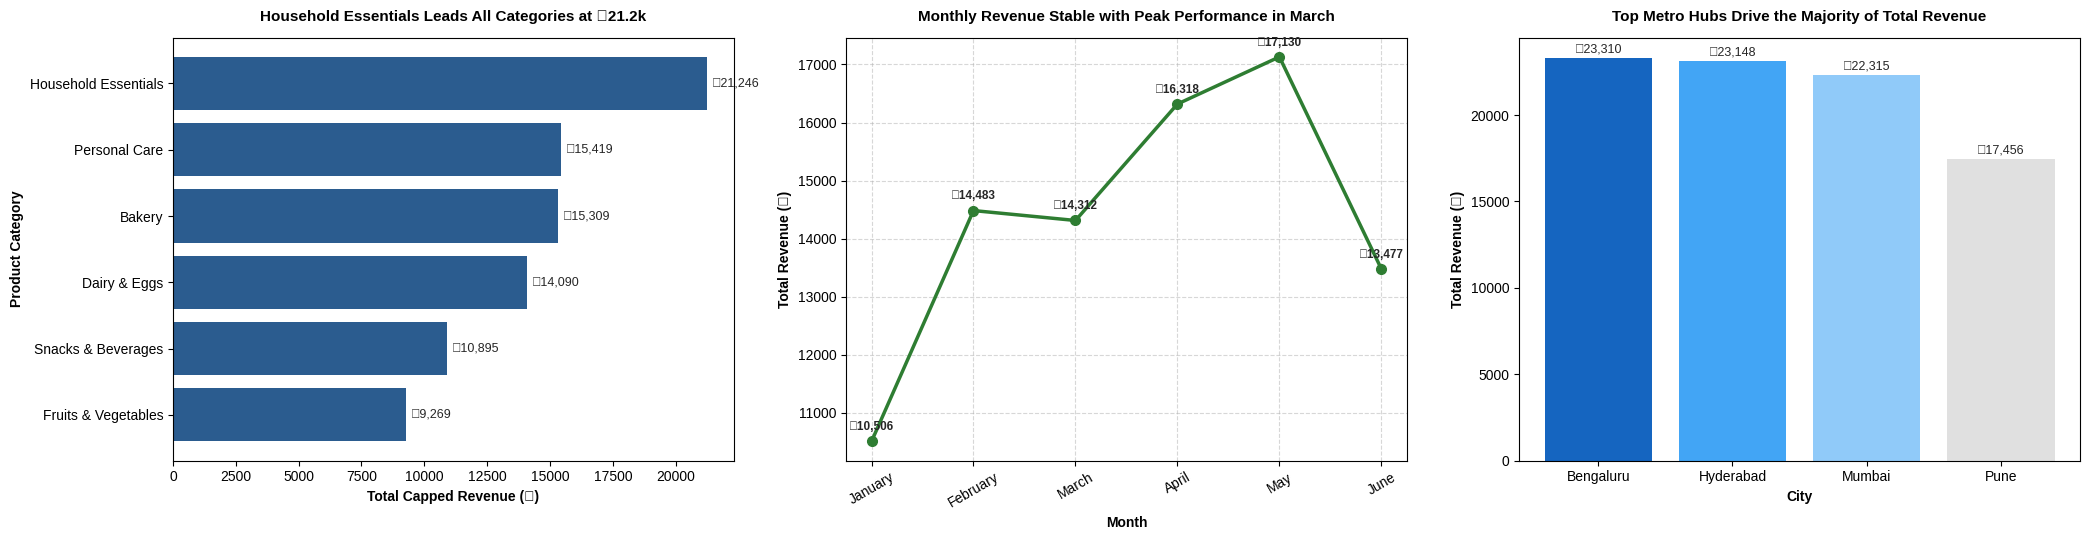

In [32]:
import matplotlib.pyplot as plt

# Filter strictly for Delivered orders with non-null amount_inr
df_delivered = df_clean[(df_clean['is_delivered']) & (df_clean['amount_inr'].notna())]

# Initialize 3-panel plot layout
fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# ---------------------------------------------------------
# Chart 1: Bar Chart - Category Revenue
# ---------------------------------------------------------
cat_rev = (
    df_delivered.groupby('category')['amount_inr']
    .sum()
    .sort_values(ascending=True)
)

axes[0].barh(cat_rev.index, cat_rev.values, color='#2b5c8f')
axes[0].set_title('Household Essentials Leads All Categories at ₹21.2k', fontsize=11, fontweight='bold', pad=12)
axes[0].set_xlabel('Total Capped Revenue (₹)', fontweight='bold')
axes[0].set_ylabel('Product Category', fontweight='bold')

for index, value in enumerate(cat_rev.values):
    axes[0].text(value + 200, index, f'₹{value:,.0f}', va='center', fontsize=9)

# ---------------------------------------------------------
# Chart 2: Line Chart - Monthly Revenue Trend
# ---------------------------------------------------------
monthly_rev = (
    df_delivered.groupby(['month', 'month_name'])['amount_inr']
    .sum()
    .reset_index()
    .sort_values('month')
)

axes[1].plot(monthly_rev['month_name'], monthly_rev['amount_inr'], marker='o', color='#2e7d32', linewidth=2.5, markersize=7)
axes[1].set_title('Monthly Revenue Stable with Peak Performance in March', fontsize=11, fontweight='bold', pad=12)
axes[1].set_xlabel('Month', fontweight='bold')
axes[1].set_ylabel('Total Revenue (₹)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, linestyle='--', alpha=0.5)

for _, row in monthly_rev.iterrows():
    axes[1].annotate(f'₹{row["amount_inr"]:,.0f}', (row['month_name'], row['amount_inr']),
                     textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8.5, fontweight='bold')

# ---------------------------------------------------------
# Chart 3: Custom Bar Chart - Revenue by City
# ---------------------------------------------------------
city_rev = (
    df_delivered.groupby('city')['amount_inr']
    .sum()
    .sort_values(ascending=False)
)

colors = ['#1565c0', '#42a5f5', '#90caf9', '#e0e0e0']
axes[2].bar(city_rev.index, city_rev.values, color=colors[:len(city_rev)])
axes[2].set_title('Top Metro Hubs Drive the Majority of Total Revenue', fontsize=11, fontweight='bold', pad=12)
axes[2].set_xlabel('City', fontweight='bold')
axes[2].set_ylabel('Total Revenue (₹)', fontweight='bold')

for index, value in enumerate(city_rev.values):
    axes[2].text(index, value + 300, f'₹{value:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Key Strategic Insights & Recommended Actions

#### 1. Category Revenue Concentration
* **What:** Household Essentials is the top revenue-generating category at ₹21,246.25, contributing over 23% of total delivered revenue and outperforming Fruits & Vegetables (₹9,268.75) by 129%.
* **Why it matters:** Revenue is heavily reliant on non-perishable daily essentials, while fresh produce and higher-margin consumables underperform in cart value.
* **Next step:** Design cross-category bundle promotions (e.g., pairing high-volume Household Essentials with Fruits & Vegetables) to lift average order value across lagging categories.

#### 2. Supplier Dependency Risk
* **What:** HomeEssentials Traders is the single largest supplier, capturing ₹21,246.25 in revenue, while the bottom two suppliers (GreenValley Traders at ₹3,778.75 and CountryEggs Farms at ₹3,020.00) combined account for under ₹7,000.
* **Why it matters:** High supply chain concentration with HomeEssentials Traders creates a critical operational dependency if supply bottlenecks or stockouts occur.
* **Next step:** Onboard alternative suppliers for core household SKUs to diversify supply chain risk and negotiate bulk pricing margins with HomeEssentials Traders.

#### 3. Impact of High-Value Order Capping
* **What:** The IQR outlier detection model identified and capped 15 extreme delivered orders at the upper fence of ₹549.38.
* **Why it matters:** Uncapped outlier orders inflate revenue expectations and distort average basket size metrics used for financial modeling and demand forecasting.
* **Next step:** Establish an operational audit workflow to investigate whether orders above ₹549.38 represent bulk commercial purchases or data entry anomalies, enabling segmented B2B handling.